# Unsupervised Learning - Market Segmentation

In this notebook, the implementation of unsupervised learning through market segmentation was done to identify the appropriate marketing strategy of a grocery firm to maximize profits.

### Import Libraries and Load the Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pingouin as pg

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity, calculate_kmo

import datetime

In [2]:
df = pd.read_csv("./Customer data-1.csv", index_col='ID')
df.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
ID,,,,,,,,,,,,,,,,,,,,,
5524,1957,Graduation,Single,58138.0,0,0,04/09/2012,58,635,88,...,7,0,0,0,0,0,0,3,11,1
2174,1954,Graduation,Single,46344.0,1,1,08/03/2014,38,11,1,...,5,0,0,0,0,0,0,3,11,0
4141,1965,Graduation,Together,71613.0,0,0,21/08/2013,26,426,49,...,4,0,0,0,0,0,0,3,11,0
6182,1984,Graduation,Together,26646.0,1,0,10/02/2014,26,11,4,...,6,0,0,0,0,0,0,3,11,0
5324,1981,PhD,Married,58293.0,1,0,19/01/2014,94,173,43,...,5,0,0,0,0,0,0,3,11,0


Inspect the Dataset

In [3]:
df.isnull().sum()

Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [4]:
df.dtypes

Year_Birth               int64
Education                  str
Marital_Status             str
Income                 float64
Kidhome                  int64
Teenhome                 int64
Dt_Customer                str
Recency                  int64
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldProds             int64
NumDealsPurchases        int64
NumWebPurchases          int64
NumCatalogPurchases      int64
NumStorePurchases        int64
NumWebVisitsMonth        int64
AcceptedCmp3             int64
AcceptedCmp4             int64
AcceptedCmp5             int64
AcceptedCmp1             int64
AcceptedCmp2             int64
Complain                 int64
Z_CostContact            int64
Z_Revenue                int64
Response                 int64
dtype: object

In [5]:
df['Education'].unique()

<StringArray>
['Graduation', 'PhD', 'Master', 'Basic', '2n Cycle']
Length: 5, dtype: str

We have to convert the string data type features into numerical ones through data transformation processes.

### Data Transformation

The Year_Birth column is in a year of birth fomrat. Hence, it is converted into age. Similarly, the Dt_Customer column is sliced to get the year to calculate the number of the customers' number of years first record.

In [6]:
current_year = datetime.datetime.now().year
df['Age'] = current_year - df['Year_Birth']

In [7]:
df['Dt_Customer'] = df['Dt_Customer'].str[-4:].astype(int)
df['Customer_Years'] = current_year - df['Dt_Customer']

The string data type features were converted into numerical data through one-hot encoding and ordinal values.

In [8]:
# Ordinal encode Education
education_map = {
    'Basic': 0,
    '2n Cycle': 1,
    'Graduation': 2,
    'Master': 3,
    'PhD': 4
}

df['Education'] = df['Education'].map(education_map)

In [9]:
df = pd.get_dummies(df, columns=['Marital_Status'], dtype=int)

In [10]:
df.columns

Index(['Year_Birth', 'Education', 'Income', 'Kidhome', 'Teenhome',
       'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts',
       'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
       'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases',
       'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3',
       'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2',
       'Complain', 'Z_CostContact', 'Z_Revenue', 'Response', 'Age',
       'Customer_Years', 'Marital_Status_Absurd', 'Marital_Status_Alone',
       'Marital_Status_Divorced', 'Marital_Status_Married',
       'Marital_Status_Single', 'Marital_Status_Together',
       'Marital_Status_Widow', 'Marital_Status_YOLO'],
      dtype='str')

### Generate new feature for total spending

Kept for later profiling/visualization only.

In [11]:
df['TotalSpending'] = (df['MntWines'] + df['MntFruits'] +
                       df['MntMeatProducts'] + df['MntFishProducts'] +
                       df['MntSweetProducts'] + df['MntGoldProds'])

drop redundant and unrelated columns

In [12]:
cols_to_drop = [
    'Year_Birth', 'Z_CostContact', 'Z_Revenue', 'Dt_Customer']

df = df.drop(columns=cols_to_drop, errors='ignore')

In [13]:
df.isnull().sum()

Education                   0
Income                     24
Kidhome                     0
Teenhome                    0
Recency                     0
MntWines                    0
MntFruits                   0
MntMeatProducts             0
MntFishProducts             0
MntSweetProducts            0
MntGoldProds                0
NumDealsPurchases           0
NumWebPurchases             0
NumCatalogPurchases         0
NumStorePurchases           0
NumWebVisitsMonth           0
AcceptedCmp3                0
AcceptedCmp4                0
AcceptedCmp5                0
AcceptedCmp1                0
AcceptedCmp2                0
Complain                    0
Response                    0
Age                         0
Customer_Years              0
Marital_Status_Absurd       0
Marital_Status_Alone        0
Marital_Status_Divorced     0
Marital_Status_Married      0
Marital_Status_Single       0
Marital_Status_Together     0
Marital_Status_Widow        0
Marital_Status_YOLO         0
TotalSpend

In [14]:
df.shape

(2240, 34)

Because the dataset is quite large with 2240 instances, drop rows when income is null

In [15]:
# Drop rows where any value is NaN
df = df.dropna()

### Separate modeling variables from profiling variables

EFA and KMO/Bartlett rest on Pearson correlations, which assume roughly continuous, linear
relationships. Running them on the full 34-column set (including one-hot Marital_Status
dummies, ordinal Education, and binary campaign/response flags) gave several per-item KMO
values below the 0.5 acceptability threshold — e.g. `Marital_Status_Divorced` (0.43),
`AcceptedCmp3` (0.49), most other `Marital_Status_*` dummies. `Recency` also failed (0.39)
despite being continuous, so it's dropped too. `TotalSpending` is an exact linear combination
of the six `Mnt*` columns, which was making the correlation matrix near-singular (the
"determinant at or very close to zero" warning) — it's excluded from modeling and kept only
for profiling/plotting.

None of the excluded variables are wasted — they're kept in `df_unscaled` and used after
clustering to describe what each segment looks like (education mix, family status, campaign
response, etc.), which is the standard split for this kind of workflow.

In [16]:
# Keep an unscaled copy of everything for later segment profiling
df_unscaled = df.copy()

# Continuous behavioral/spending variables used for EFA + clustering
continuous_cols = [
    'Income', 'MntWines', 'MntFruits', 'MntMeatProducts',
    'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
    'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases',
    'NumStorePurchases', 'NumWebVisitsMonth', 'Age', 'Customer_Years'
]

# Everything else (Education, Kidhome, Teenhome, Marital_Status_*,
# AcceptedCmp1-5, Complain, Response, Recency, TotalSpending) stays in
# df_unscaled for profiling later, but is NOT part of the modeling set.

df_unscaled[continuous_cols].describe().T[['mean', 'std', 'min', 'max']]

,mean,std,min,max
Income,52247.251354,25173.076661,1730.0,666666.0
MntWines,305.091606,337.327920,0.0,1493.0
MntFruits,26.356047,39.793917,0.0,199.0
MntMeatProducts,166.995939,224.283273,0.0,1725.0
MntFishProducts,37.637635,54.752082,0.0,259.0
MntSweetProducts,27.028881,41.072046,0.0,262.0
MntGoldProds,43.965253,51.815414,0.0,321.0
NumDealsPurchases,2.323556,1.923716,0.0,15.0
NumWebPurchases,4.085289,2.740951,0.0,27.0
NumCatalogPurchases,2.671029,2.926734,0.0,28.0


### Scale the continuous modeling set

In [17]:
scaler = StandardScaler()
df_fa = pd.DataFrame(
    scaler.fit_transform(df_unscaled[continuous_cols]),
    columns=continuous_cols,
    index=df_unscaled.index
)
df_fa.head()

,Income,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Age,Customer_Years
ID,,,,,,,,,,,,,,
5524,0.234063,0.978226,1.549429,1.690227,2.454568,1.484827,0.850031,0.351713,1.428553,2.504712,-0.554143,0.693232,0.986443,1.500343
2174,-0.234559,-0.872024,-0.637328,-0.717986,-0.651038,-0.633880,-0.732867,-0.168231,-1.125881,-0.571082,-1.169518,-0.131574,1.236801,-1.417393
4141,0.769478,0.358511,0.569159,-0.178368,1.340203,-0.146821,-0.037937,-0.688176,1.428553,-0.229327,1.291982,-0.543978,0.318822,0.041475
6182,-1.017239,-0.872024,-0.561922,-0.655551,-0.504892,-0.585174,-0.752171,-0.168231,-0.760962,-0.912837,-0.554143,0.280829,-1.266777,-1.417393
5324,0.240221,-0.391671,0.418348,-0.218505,0.152766,-0.000703,-0.559135,1.391603,0.333796,0.112428,0.061232,-0.131574,-1.016420,-1.417393


In [18]:
df_fa.isnull().sum()

Income                 0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Age                    0
Customer_Years         0
dtype: int64

### Sampling adequacy on the trimmed continuous features

In [19]:
chi_square_value, p_value = calculate_bartlett_sphericity(df_fa)
print(f"Bartlett's test p-value: {p_value}")

Bartlett's test p-value: 0.0


In [20]:
kmo_all, kmo_model = calculate_kmo(df_fa)
print(f"Overall KMO: {kmo_model:.3f}")

kmo_series = pd.Series(kmo_all, index=continuous_cols).sort_values()
kmo_series

Overall KMO: 0.887


NumDealsPurchases      0.573830
Customer_Years         0.615758
Age                    0.729897
NumWebVisitsMonth      0.795806
NumWebPurchases        0.847865
MntWines               0.871035
NumStorePurchases      0.887693
NumCatalogPurchases    0.897446
MntMeatProducts        0.908437
MntFishProducts        0.929552
MntGoldProds           0.931113
MntFruits              0.931752
MntSweetProducts       0.935347
Income                 0.935905
dtype: float64

In [21]:
low_kmo = kmo_series[kmo_series < 0.5]
if len(low_kmo):
    print("Below 0.5 KMO -- consider dropping and re-running KMO:")
    print(low_kmo)
else:
    print("All items clear the 0.5 KMO threshold.")

All items clear the 0.5 KMO threshold.


In [22]:
fa = FactorAnalyzer(rotation=None)
fa.fit(df_fa)

ev, v = fa.get_eigenvalues()
ev

array([5.67604207, 1.74067572, 1.16563964, 0.82025688, 0.78996411,
       0.66285177, 0.63671328, 0.48652835, 0.43603025, 0.41555237,
       0.38778153, 0.31675703, 0.24891529, 0.21629172])

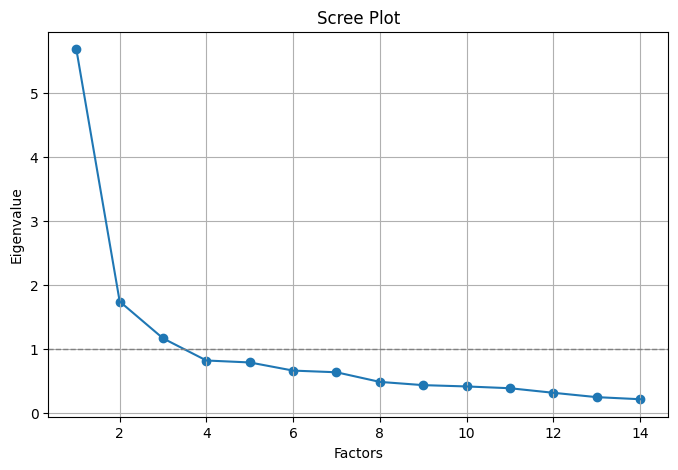

Factors with eigenvalue > 1 (Kaiser criterion): 3


In [23]:
plt.figure(figsize=(8, 5))
plt.scatter(range(1, df_fa.shape[1] + 1), ev)
plt.plot(range(1, df_fa.shape[1] + 1), ev)
plt.axhline(y=1, color='grey', linestyle='--', linewidth=1)
plt.title('Scree Plot')
plt.xlabel('Factors')
plt.ylabel('Eigenvalue')
plt.grid()
plt.show()

n_factors = int(sum(ev > 1))
print(f"Factors with eigenvalue > 1 (Kaiser criterion): {n_factors}")

`n_factors` is set automatically from the Kaiser criterion (eigenvalue > 1). This is further validated by the scree plot where the elbow clearly suggests a different number (4), so override `n_factors` manually before the next cell.

In [24]:
n_factors = 4

In [25]:
fa = FactorAnalyzer(n_factors=n_factors, rotation="varimax")
fa.fit(df_fa)

loadings_df = pd.DataFrame(
    fa.loadings_,
    index=continuous_cols,
    columns=[f'Factor_{i+1}' for i in range(n_factors)]
)
loadings_df.round(3)

,Factor_1,Factor_2,Factor_3,Factor_4
Income,0.387,0.439,0.457,-0.173
MntWines,0.354,0.486,0.537,0.158
MntFruits,0.726,0.219,0.072,-0.077
MntMeatProducts,0.509,0.713,0.111,-0.078
MntFishProducts,0.736,0.262,0.062,-0.082
MntSweetProducts,0.696,0.228,0.102,-0.066
MntGoldProds,0.478,0.180,0.236,0.144
NumDealsPurchases,-0.119,-0.073,0.173,0.458
NumWebPurchases,0.379,0.092,0.573,0.396
NumCatalogPurchases,0.452,0.656,0.296,-0.008


### Reliability of each factor (Cronbach's alpha)

In [26]:
def get_factor_items(loadings_df, threshold=0.4):
    """Group items by factor, keeping only loadings at or above `threshold`."""
    factor_items = {}
    for factor in loadings_df.columns:
        items = loadings_df.index[loadings_df[factor].abs() >= threshold].tolist()
        factor_items[factor] = items
    return factor_items

factor_items = get_factor_items(loadings_df)

for factor, items in factor_items.items():
    if len(items) >= 2:
        alpha = pg.cronbach_alpha(data=df_fa[items])[0]
        print(f"{factor} ({len(items)} items): alpha = {alpha:.3f} -> {items}")
    else:
        print(f"{factor}: fewer than 2 items above threshold, skipping alpha -> {items}")

Factor_1 (7 items): alpha = 0.873 -> ['MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumCatalogPurchases', 'NumStorePurchases']
Factor_2 (4 items): alpha = 0.865 -> ['Income', 'MntWines', 'MntMeatProducts', 'NumCatalogPurchases']
Factor_3 (4 items): alpha = 0.821 -> ['Income', 'MntWines', 'NumWebPurchases', 'NumStorePurchases']
Factor_4 (3 items): alpha = 0.515 -> ['NumDealsPurchases', 'NumWebVisitsMonth', 'Customer_Years']


### Factor scores -> clustering input

In [27]:
factor_scores = fa.transform(df_fa)

df_factors = pd.DataFrame(
    factor_scores,
    columns=[f'Factor_{i+1}' for i in range(n_factors)],
    index=df_fa.index
)
df_factors.head()

,Factor_1,Factor_2,Factor_3,Factor_4
ID,,,,
5524,1.701267,1.371376,-0.766018,1.779819
2174,-0.863234,-0.332140,-0.290483,-0.936469
4141,0.837351,-0.746902,1.061140,-0.199135
6182,-0.521935,-0.593957,-0.602176,-0.445200
5324,0.145219,-0.353877,0.231880,-0.185614


### Choosing k: elbow + silhouette together

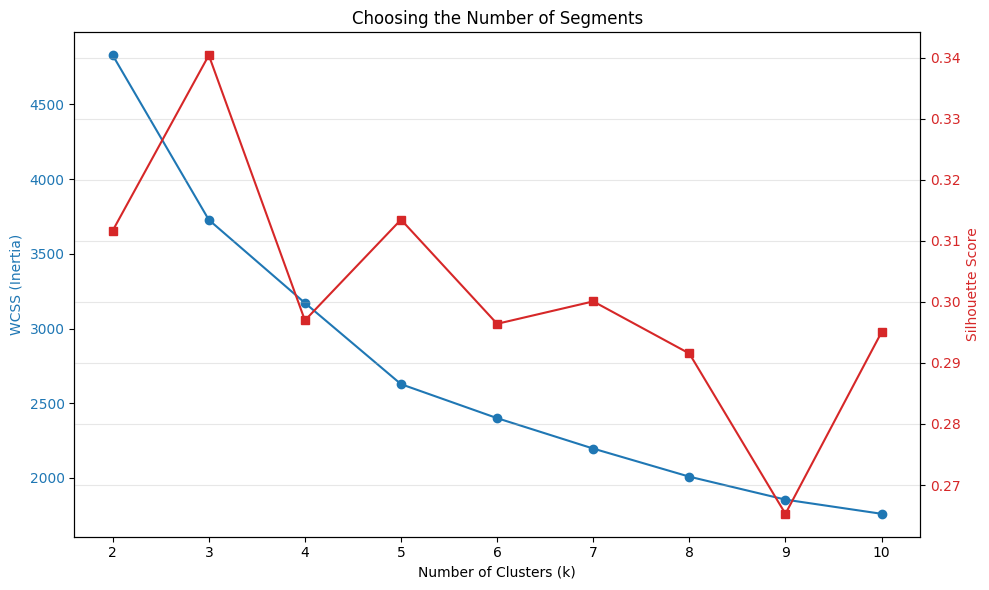

Highest silhouette score at k = 3


In [28]:
wcss = []
silhouette_avg = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(df_factors)
    wcss.append(kmeans.inertia_)
    silhouette_avg.append(silhouette_score(df_factors, cluster_labels))

fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:blue'
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('WCSS (Inertia)', color=color)
ax1.plot(k_range, wcss, marker='o', color=color, label='WCSS')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Silhouette Score', color=color)
ax2.plot(k_range, silhouette_avg, marker='s', color=color, label='Silhouette Score')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Choosing the Number of Segments')
plt.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

print(f"Highest silhouette score at k = {k_range[int(np.argmax(silhouette_avg))]}")

Set `optimal_k` from what the plot above actually shows (highest silhouette, and/or the
elbow in WCSS).

In [29]:
optimal_k = k_range[int(np.argmax(silhouette_avg))]  # override manually if the elbow disagrees

kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_factors['Customer_Segment'] = kmeans_final.fit_predict(df_factors)

print("Customers per segment:")
print(df_factors['Customer_Segment'].value_counts())

df_factors.groupby('Customer_Segment').mean(numeric_only=True)

Customers per segment:
Customer_Segment
0    1063
2     633
1     520
Name: count, dtype: int64


,Factor_1,Factor_2,Factor_3,Factor_4
Customer_Segment,,,,
0,-0.521528,-0.414716,-0.512495,-0.222083
1,1.045396,0.871202,0.101280,-0.559527
2,0.017027,-0.019246,0.777436,0.832587


### Profile the segments using the variables held out of modeling

In [30]:
df_unscaled['Customer_Segment'] = df_factors['Customer_Segment'].values

segment_profile = df_unscaled.groupby('Customer_Segment').mean(numeric_only=True).round(1)
pd.set_option('display.max_columns', None)
segment_profile

,Education,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Age,Customer_Years,Marital_Status_Absurd,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO,TotalSpending
Customer_Segment,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,2.3,36349.4,0.7,0.5,49.0,48.7,6.3,25.5,9.1,6.1,15.8,2.0,2.1,0.7,3.5,6.1,0.1,0.0,0.0,0.0,0.0,0.0,0.1,55.0,12.8,0.0,0.0,0.1,0.4,0.2,0.3,0.0,0.0,111.6
1,2.4,75968.8,0.0,0.2,49.2,558.2,70.1,470.1,102.6,70.6,76.6,1.3,4.7,5.9,8.2,2.4,0.1,0.1,0.2,0.2,0.0,0.0,0.2,57.5,12.9,0.0,0.0,0.1,0.4,0.2,0.3,0.0,0.0,1348.2
2,2.7,59457.7,0.3,0.8,48.9,527.6,24.0,155.7,32.2,26.4,64.4,3.7,6.9,3.4,7.7,6.3,0.1,0.2,0.1,0.1,0.0,0.0,0.2,60.5,13.2,0.0,0.0,0.1,0.4,0.2,0.3,0.0,0.0,830.4


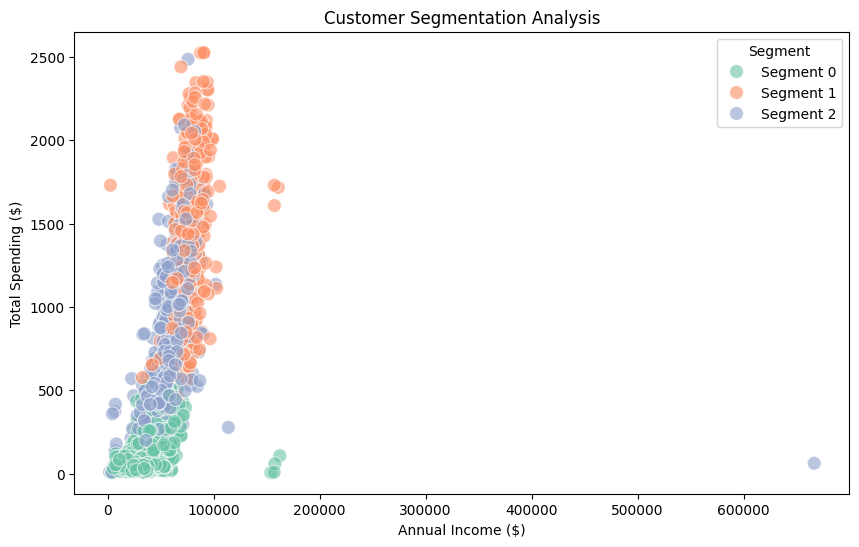

In [31]:
segment_names = {i: f'Segment {i}' for i in range(optimal_k)}  # rename based on segment_profile

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_unscaled,
    x='Income',
    y='TotalSpending',
    hue='Customer_Segment',
    palette='Set2',
    s=100,
    alpha=0.6
)

plt.title('Customer Segmentation Analysis')
plt.xlabel('Annual Income ($)')
plt.ylabel('Total Spending ($)')

handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles,
           [segment_names[int(l)] for l in labels],
           title='Segment')

plt.savefig('cluster_visualization.png', dpi=300, bbox_inches='tight')
plt.show()